# Dataset Poisoning Exploration
Use this notebook to visualize the datasets generated by the pipeline.

In [4]:
import sys
import os
# Add scripts to path so we can import dataset_utils
sys.path.append(os.path.abspath('../scripts'))

import torch
import matplotlib.pyplot as plt
import pickle
from dataset_utils import PoisonedDataset, BackdoorDataset
import numpy as np

## 1. Visualize Background Datasets
Let's compare the Label Flip and Backdoor Trigger datasets.

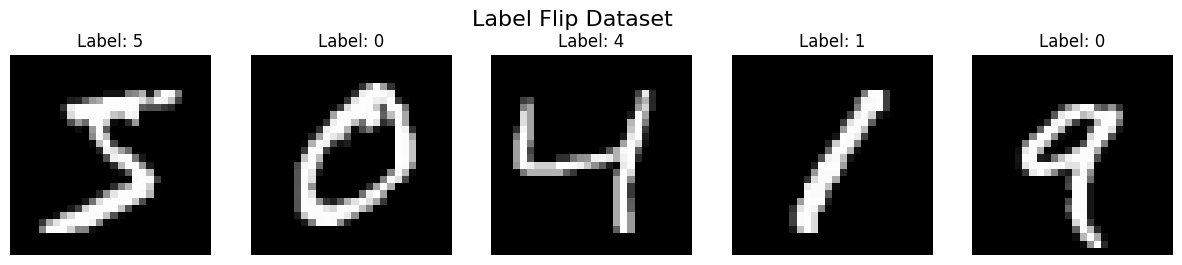

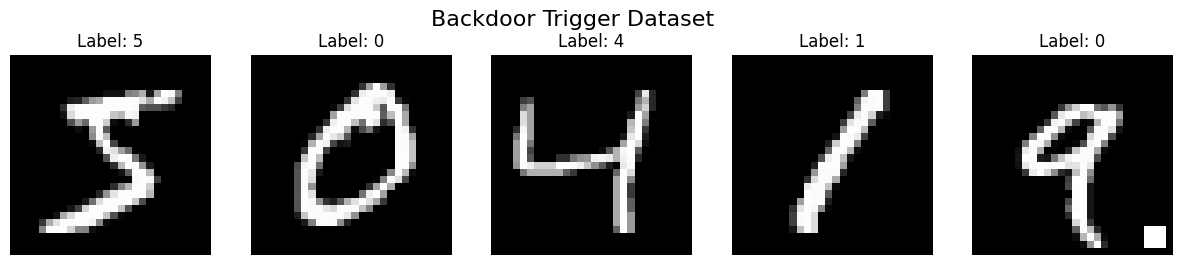

In [5]:
def show_samples(dataset_path, title, num_samples=5):
    with open(dataset_path, 'rb') as f:
        dataset = pickle.load(f)
    
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num_samples):
        img, label = dataset[i]
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.show()

if os.path.exists('../data/processed/label_flip_dataset.pkl'):
    show_samples('../data/processed/label_flip_dataset.pkl', "Label Flip Dataset")
if os.path.exists('../data/processed/backdoor_dataset.pkl'):
    show_samples('../data/processed/backdoor_dataset.pkl', "Backdoor Trigger Dataset")

## 2. Detection Results
Let's look at a few samples that our algorithms flagged as poisoned.

In [6]:
# Load ground truth and autoencoder flags
poison_indices = np.load('../data/processed/poison_indices.npy')
ae_flags = np.load('../data/processed/label_flip_ae_flags.npy')

print(f"Total ground truth poisoned samples: {len(poison_indices)}")
print(f"Total samples flagged by Autoencoder: {np.sum(ae_flags)}")

Total ground truth poisoned samples: 6000
Total samples flagged by Autoencoder: 6000
